In [29]:
# Data Manipulation
import pandas as pd
import numpy as np

# Database Connectivity
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Date & Time
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ttest_ind

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)



# Plot Settings
plt.style.use('default')
%matplotlib inline

In [2]:
# Connect to database
conn = sqlite3.connect('inventory.db')

# Load Vendor Sales Summary table
df = pd.read_sql("""
SELECT * 
FROM vendor_sales_summary
""", conn)


In [11]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.00,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.00,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.00,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.00,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.00,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.00,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,22.33,28.06
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.00,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,1.00,1.34
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.00,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.97,72.00,97.47
10691,7245,PROXIMO SPIRITS INC.,3065,Three Olives Grape Vodka,0.71,0.99,50.00,1,0.71,86,85.14,33.66,4.46,38994.78,84.43,99.17,86.00,119.92


# Exploratory Data Analysis

* Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [12]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10693.00,10649.89,18752.81,2.00,3951.00,7153.00,9552.00,201359.00
Brand,10693.00,18037.74,12662.53,58.00,5789.00,18761.00,25514.00,90631.00
PurchasePrice,10693.00,24.38,109.26,0.00,6.84,10.45,19.47,5681.81
ActualPrice,10693.00,35.64,148.24,0.00,10.99,15.99,28.99,7499.99
Volume,10693.00,847.35,664.28,50.00,750.00,750.00,750.00,20000.00
TotalPurchaseQuantity,10693.00,3140.78,11094.57,1.00,36.00,262.00,1978.00,337660.00
TotalPurchaseDollars,10693.00,30103.88,123062.39,0.00,453.18,3655.23,20733.42,3811251.60
TotalSalesQuantity,10693.00,3077.36,10952.35,0.00,33.00,261.00,1929.00,334939.00
TotalSalesDollars,10693.00,42244.31,167648.30,0.00,729.27,5298.21,28406.05,5101919.51
TotalSalesPrice,10693.00,18797.69,44952.48,0.00,289.71,2857.80,16075.38,672819.31


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10693 entries, 0 to 10692
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10693 non-null  int64  
 1   VendorName             10693 non-null  object 
 2   Brand                  10693 non-null  int64  
 3   Description            10693 non-null  object 
 4   PurchasePrice          10693 non-null  float64
 5   ActualPrice            10693 non-null  float64
 6   Volume                 10693 non-null  float64
 7   TotalPurchaseQuantity  10693 non-null  int64  
 8   TotalPurchaseDollars   10693 non-null  float64
 9   TotalSalesQuantity     10693 non-null  int64  
 10  TotalSalesDollars      10693 non-null  float64
 11  TotalSalesPrice        10693 non-null  float64
 12  TotalExciseTax         10693 non-null  float64
 13  FreightCost            10693 non-null  float64
 14  GrossProfit            10693 non-null  float64
 15  Pr

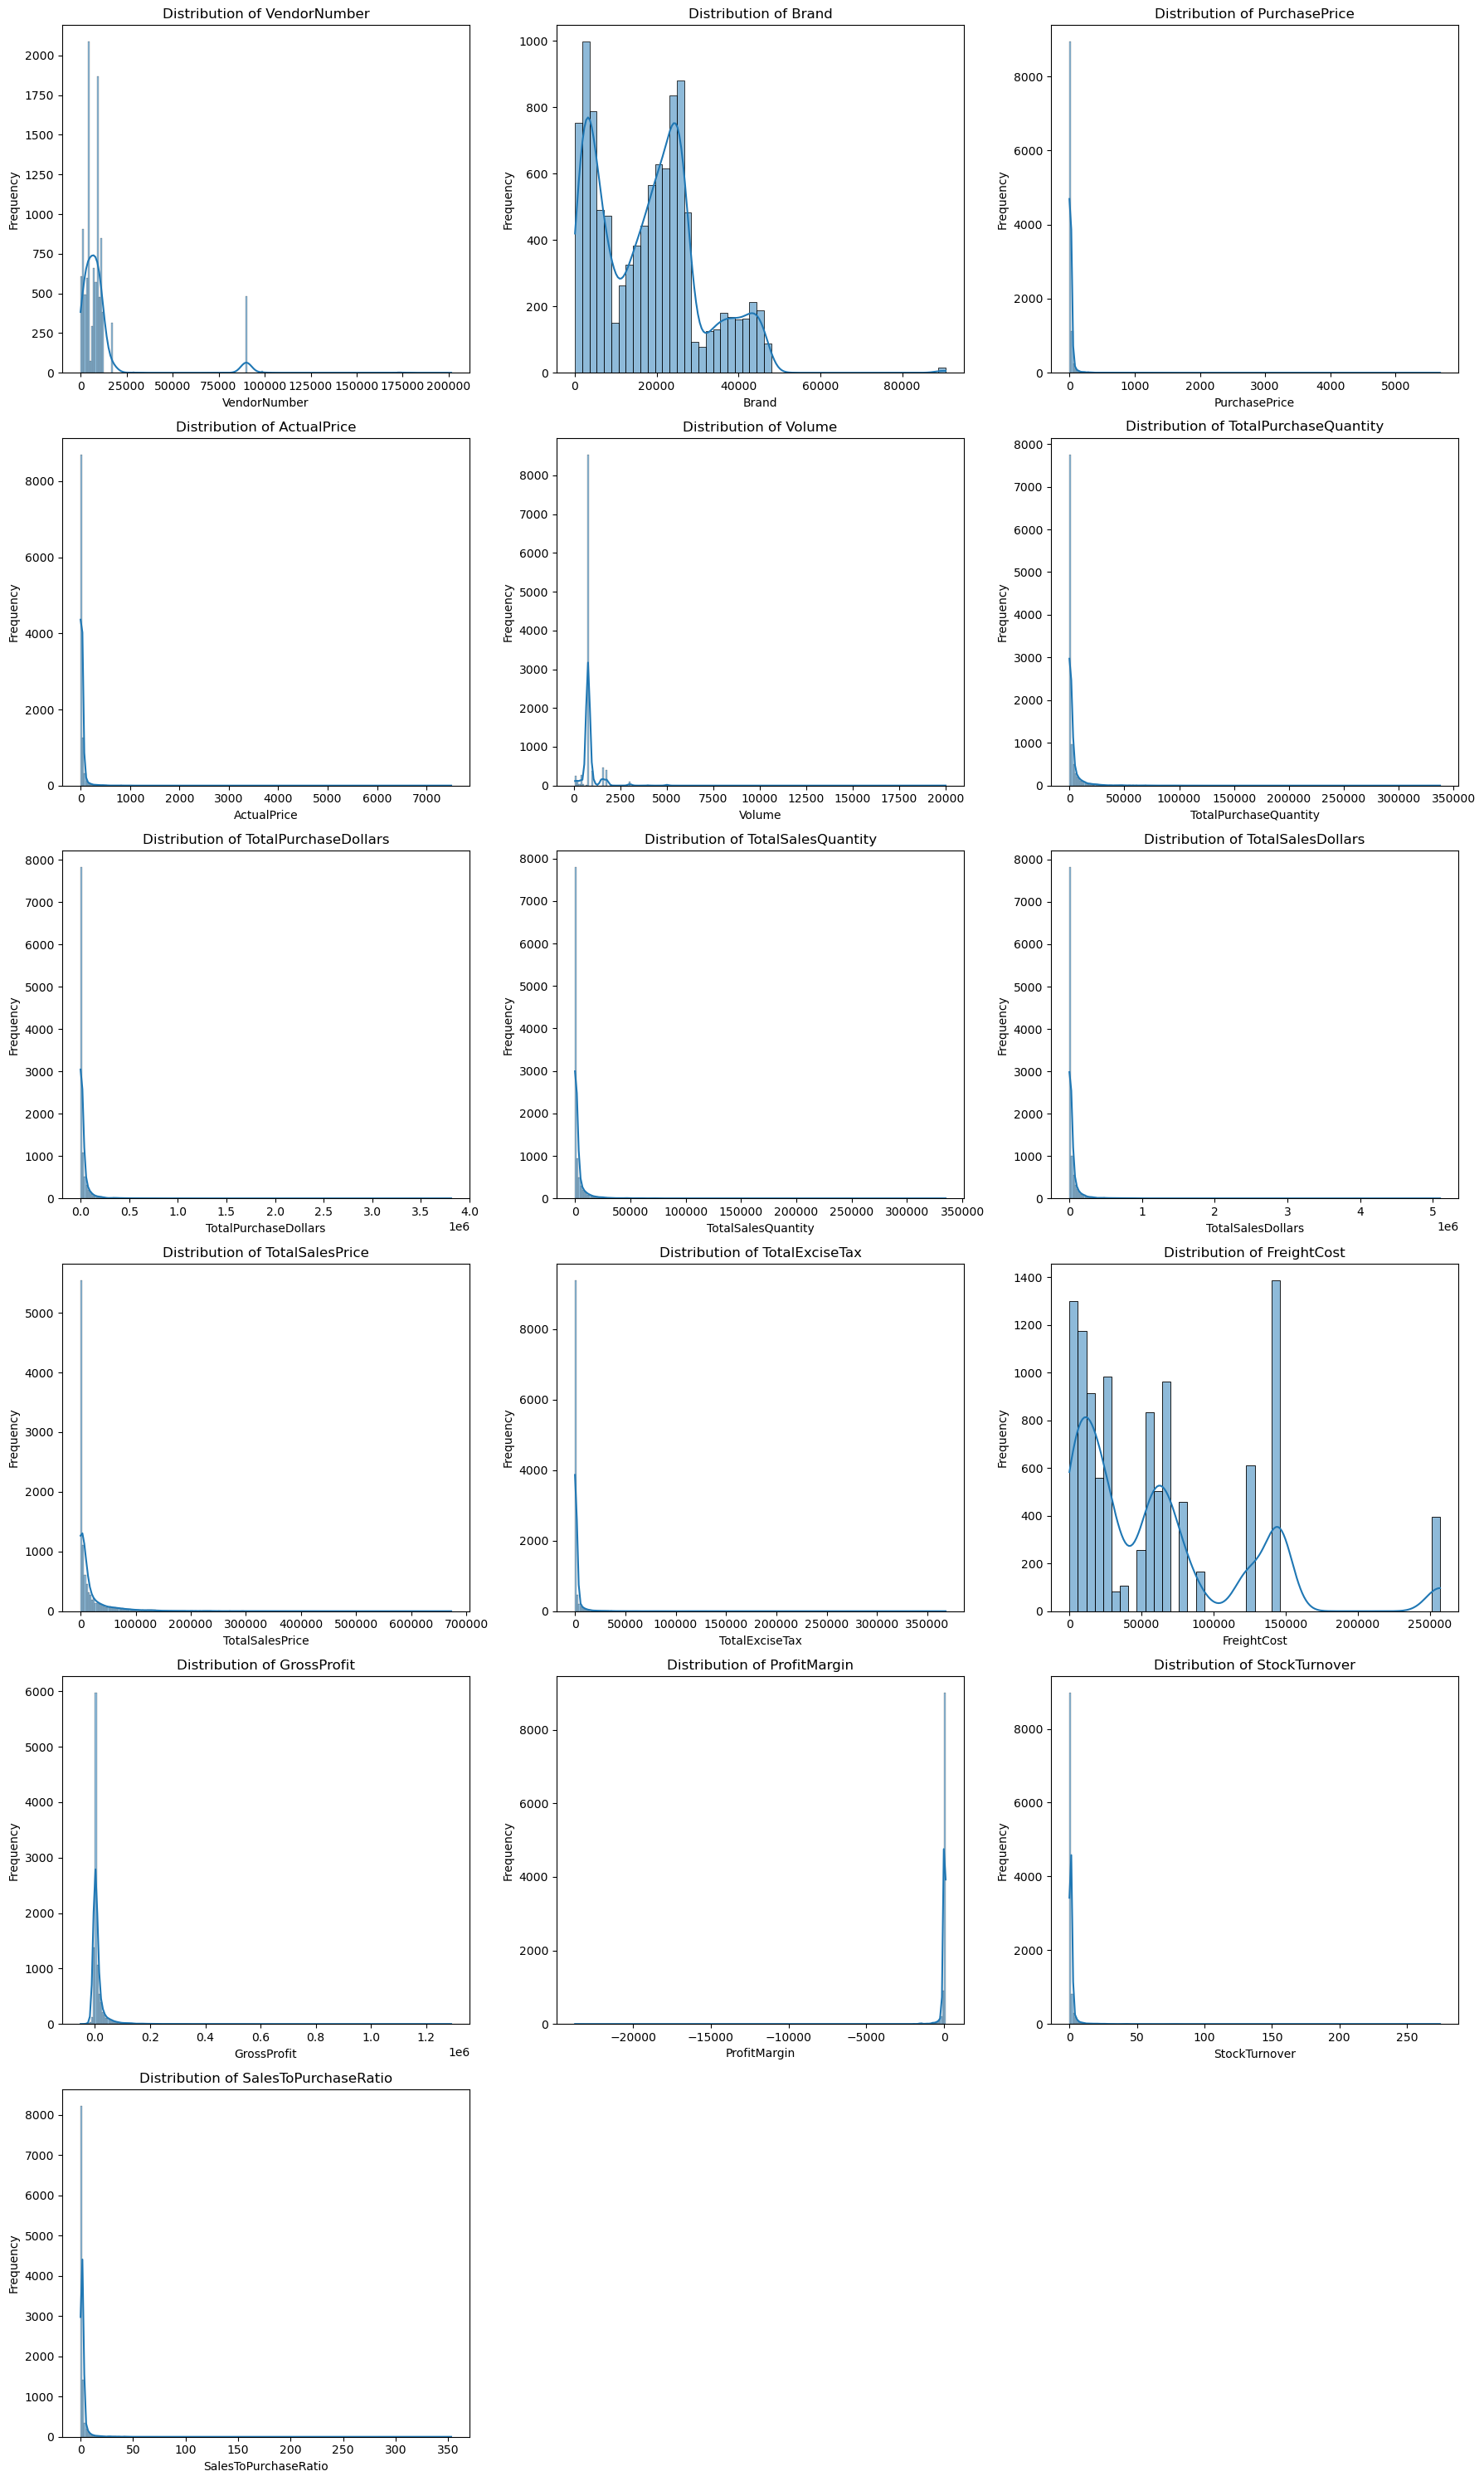

In [16]:
# Select all numerical columns automatically
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Define subplot grid
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot distributions
for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

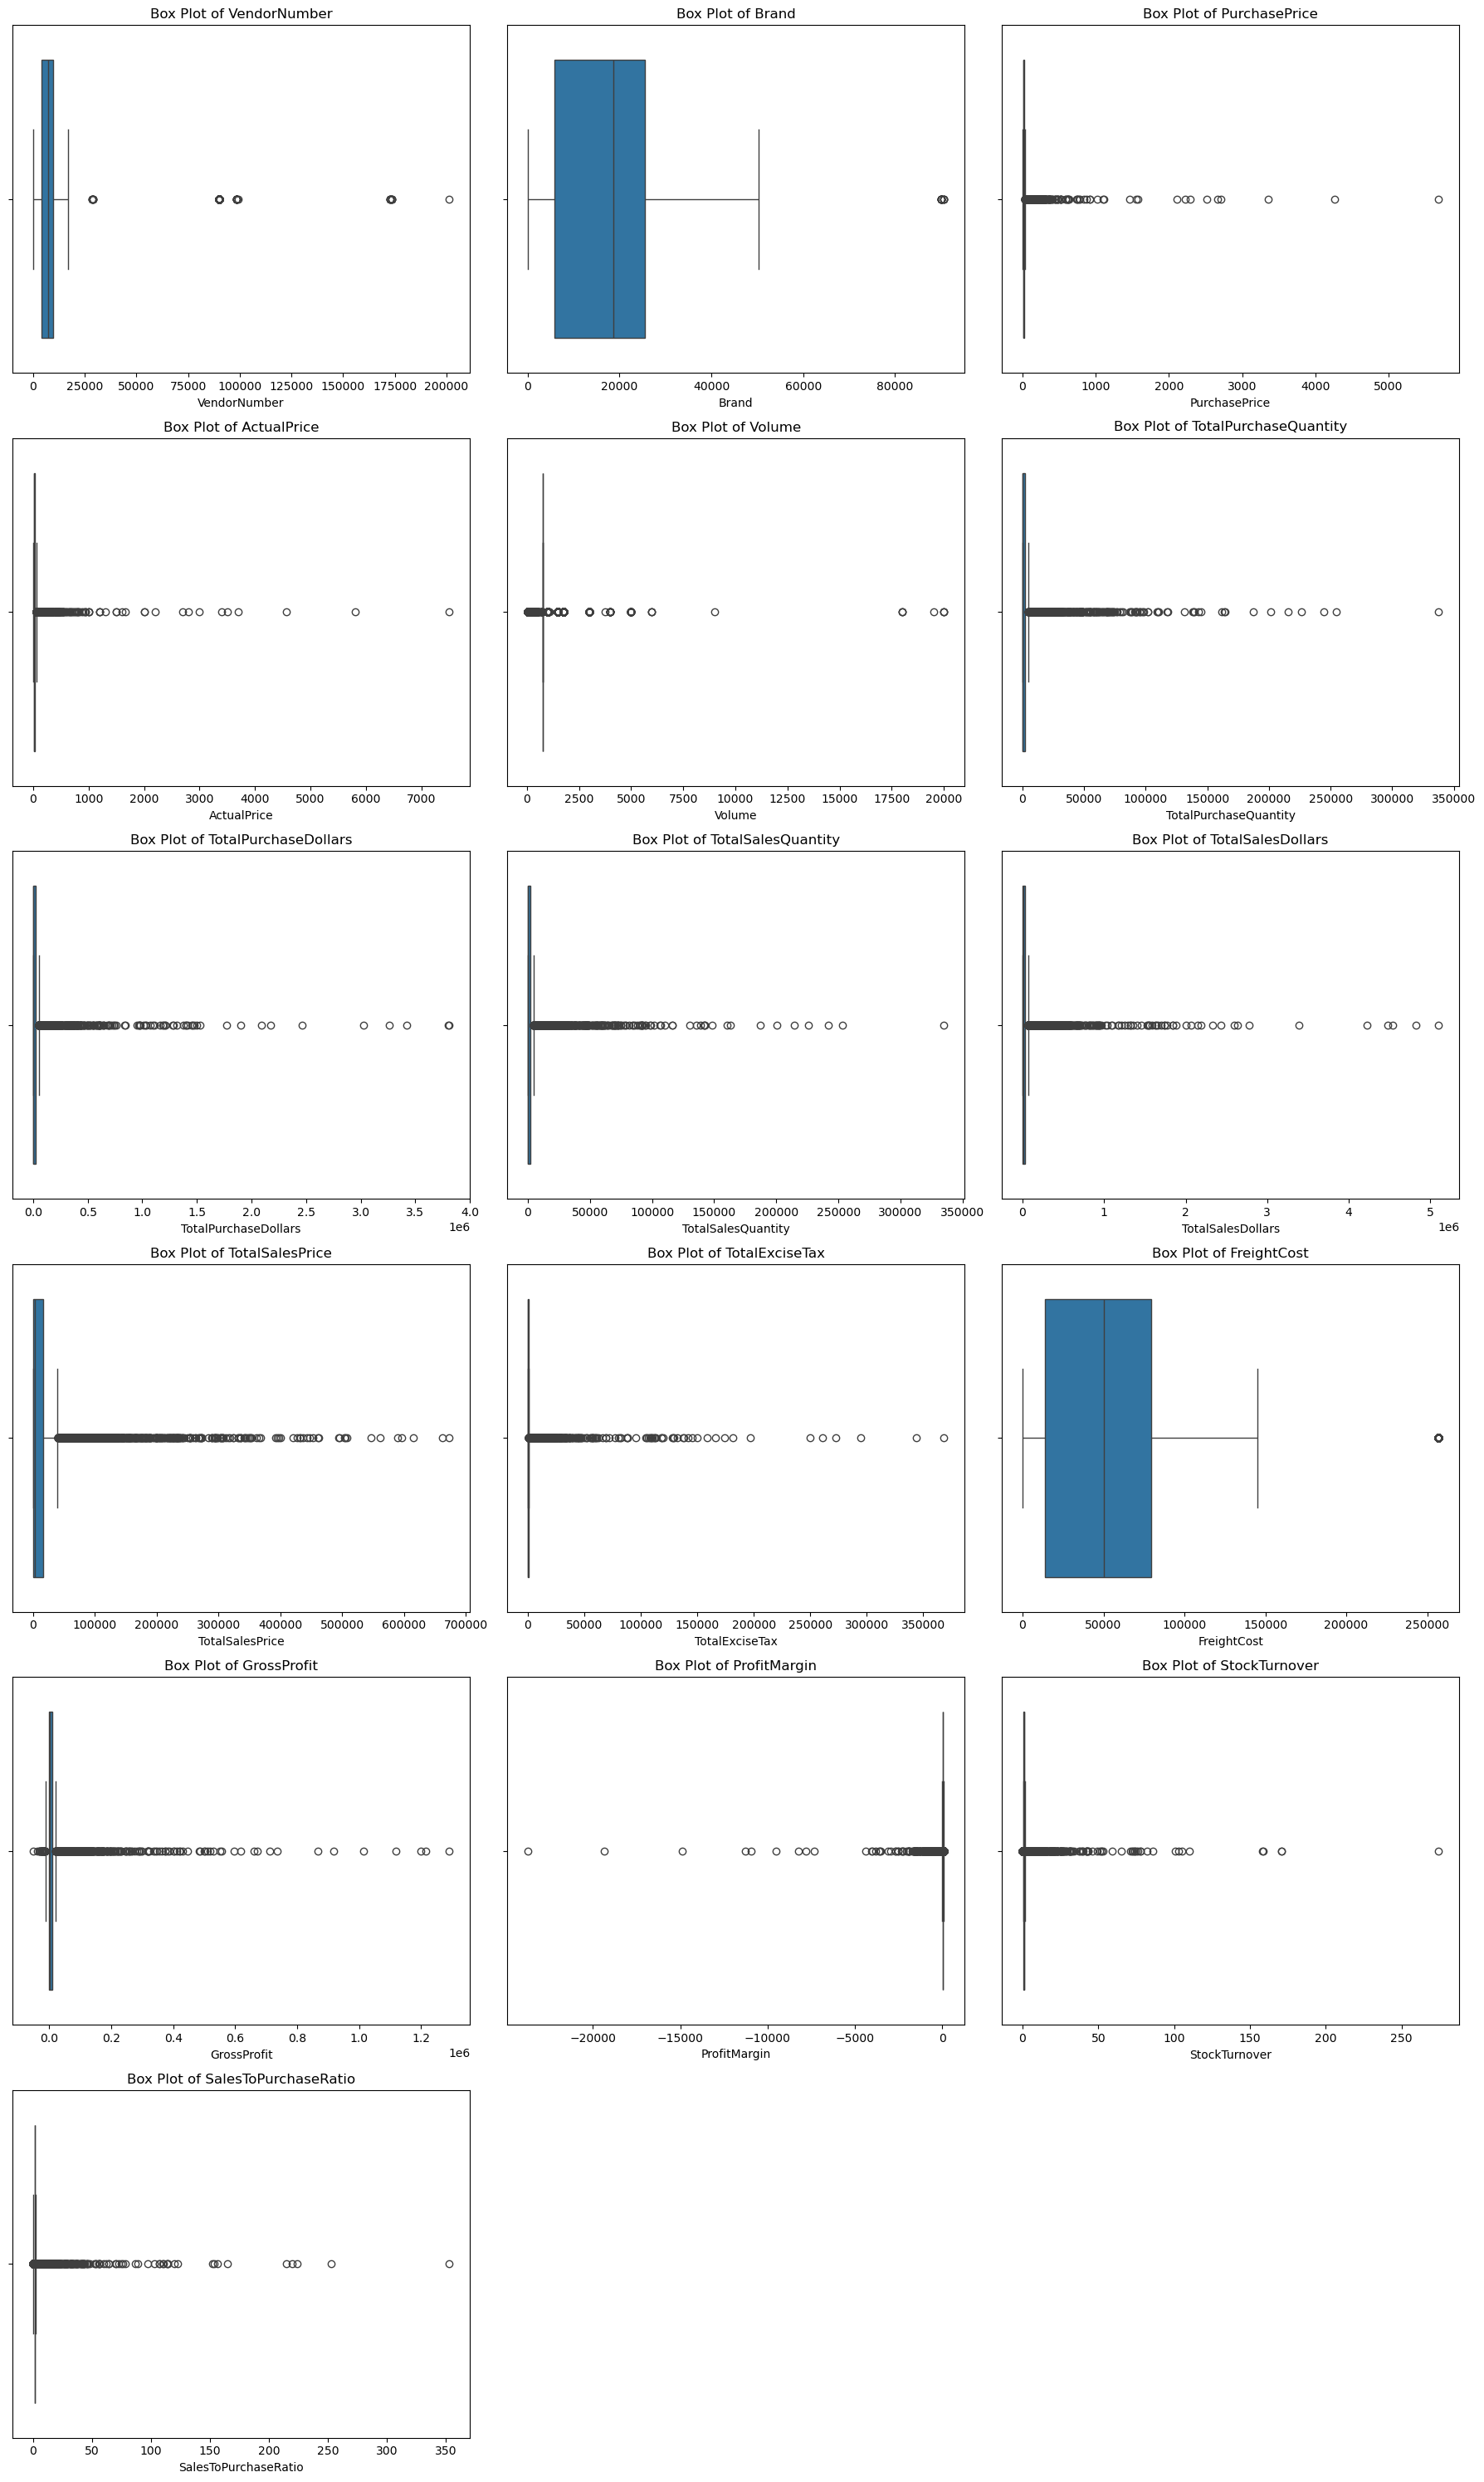

In [13]:
# Select all numerical columns automatically
numerical_cols = vendor_sales_summary.select_dtypes(
    include=['int64', 'float64']
).columns

# Define subplot grid
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Create boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=vendor_sales_summary[col],
        ax=axes[i]
    )
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Summary Statistics Insights:

**Negative & Zero Values:**

* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
* Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [3]:
# lets filter the data by removing the inconsistency
df = pd.read_sql_query("""SELECT * FROM vendor_sales_summary
                            WHERE GrossProfit > 0 AND ProfitMargin > 0 AND TotalSalesQuantity > 0 ;""",conn)

In [18]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.00,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.00,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.00,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.00,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.00,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.00,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,22.33,28.06
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.00,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,1.00,1.34
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.00,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.97,72.00,97.47
8563,7245,PROXIMO SPIRITS INC.,3065,Three Olives Grape Vodka,0.71,0.99,50.00,1,0.71,86,85.14,33.66,4.46,38994.78,84.43,99.17,86.00,119.92


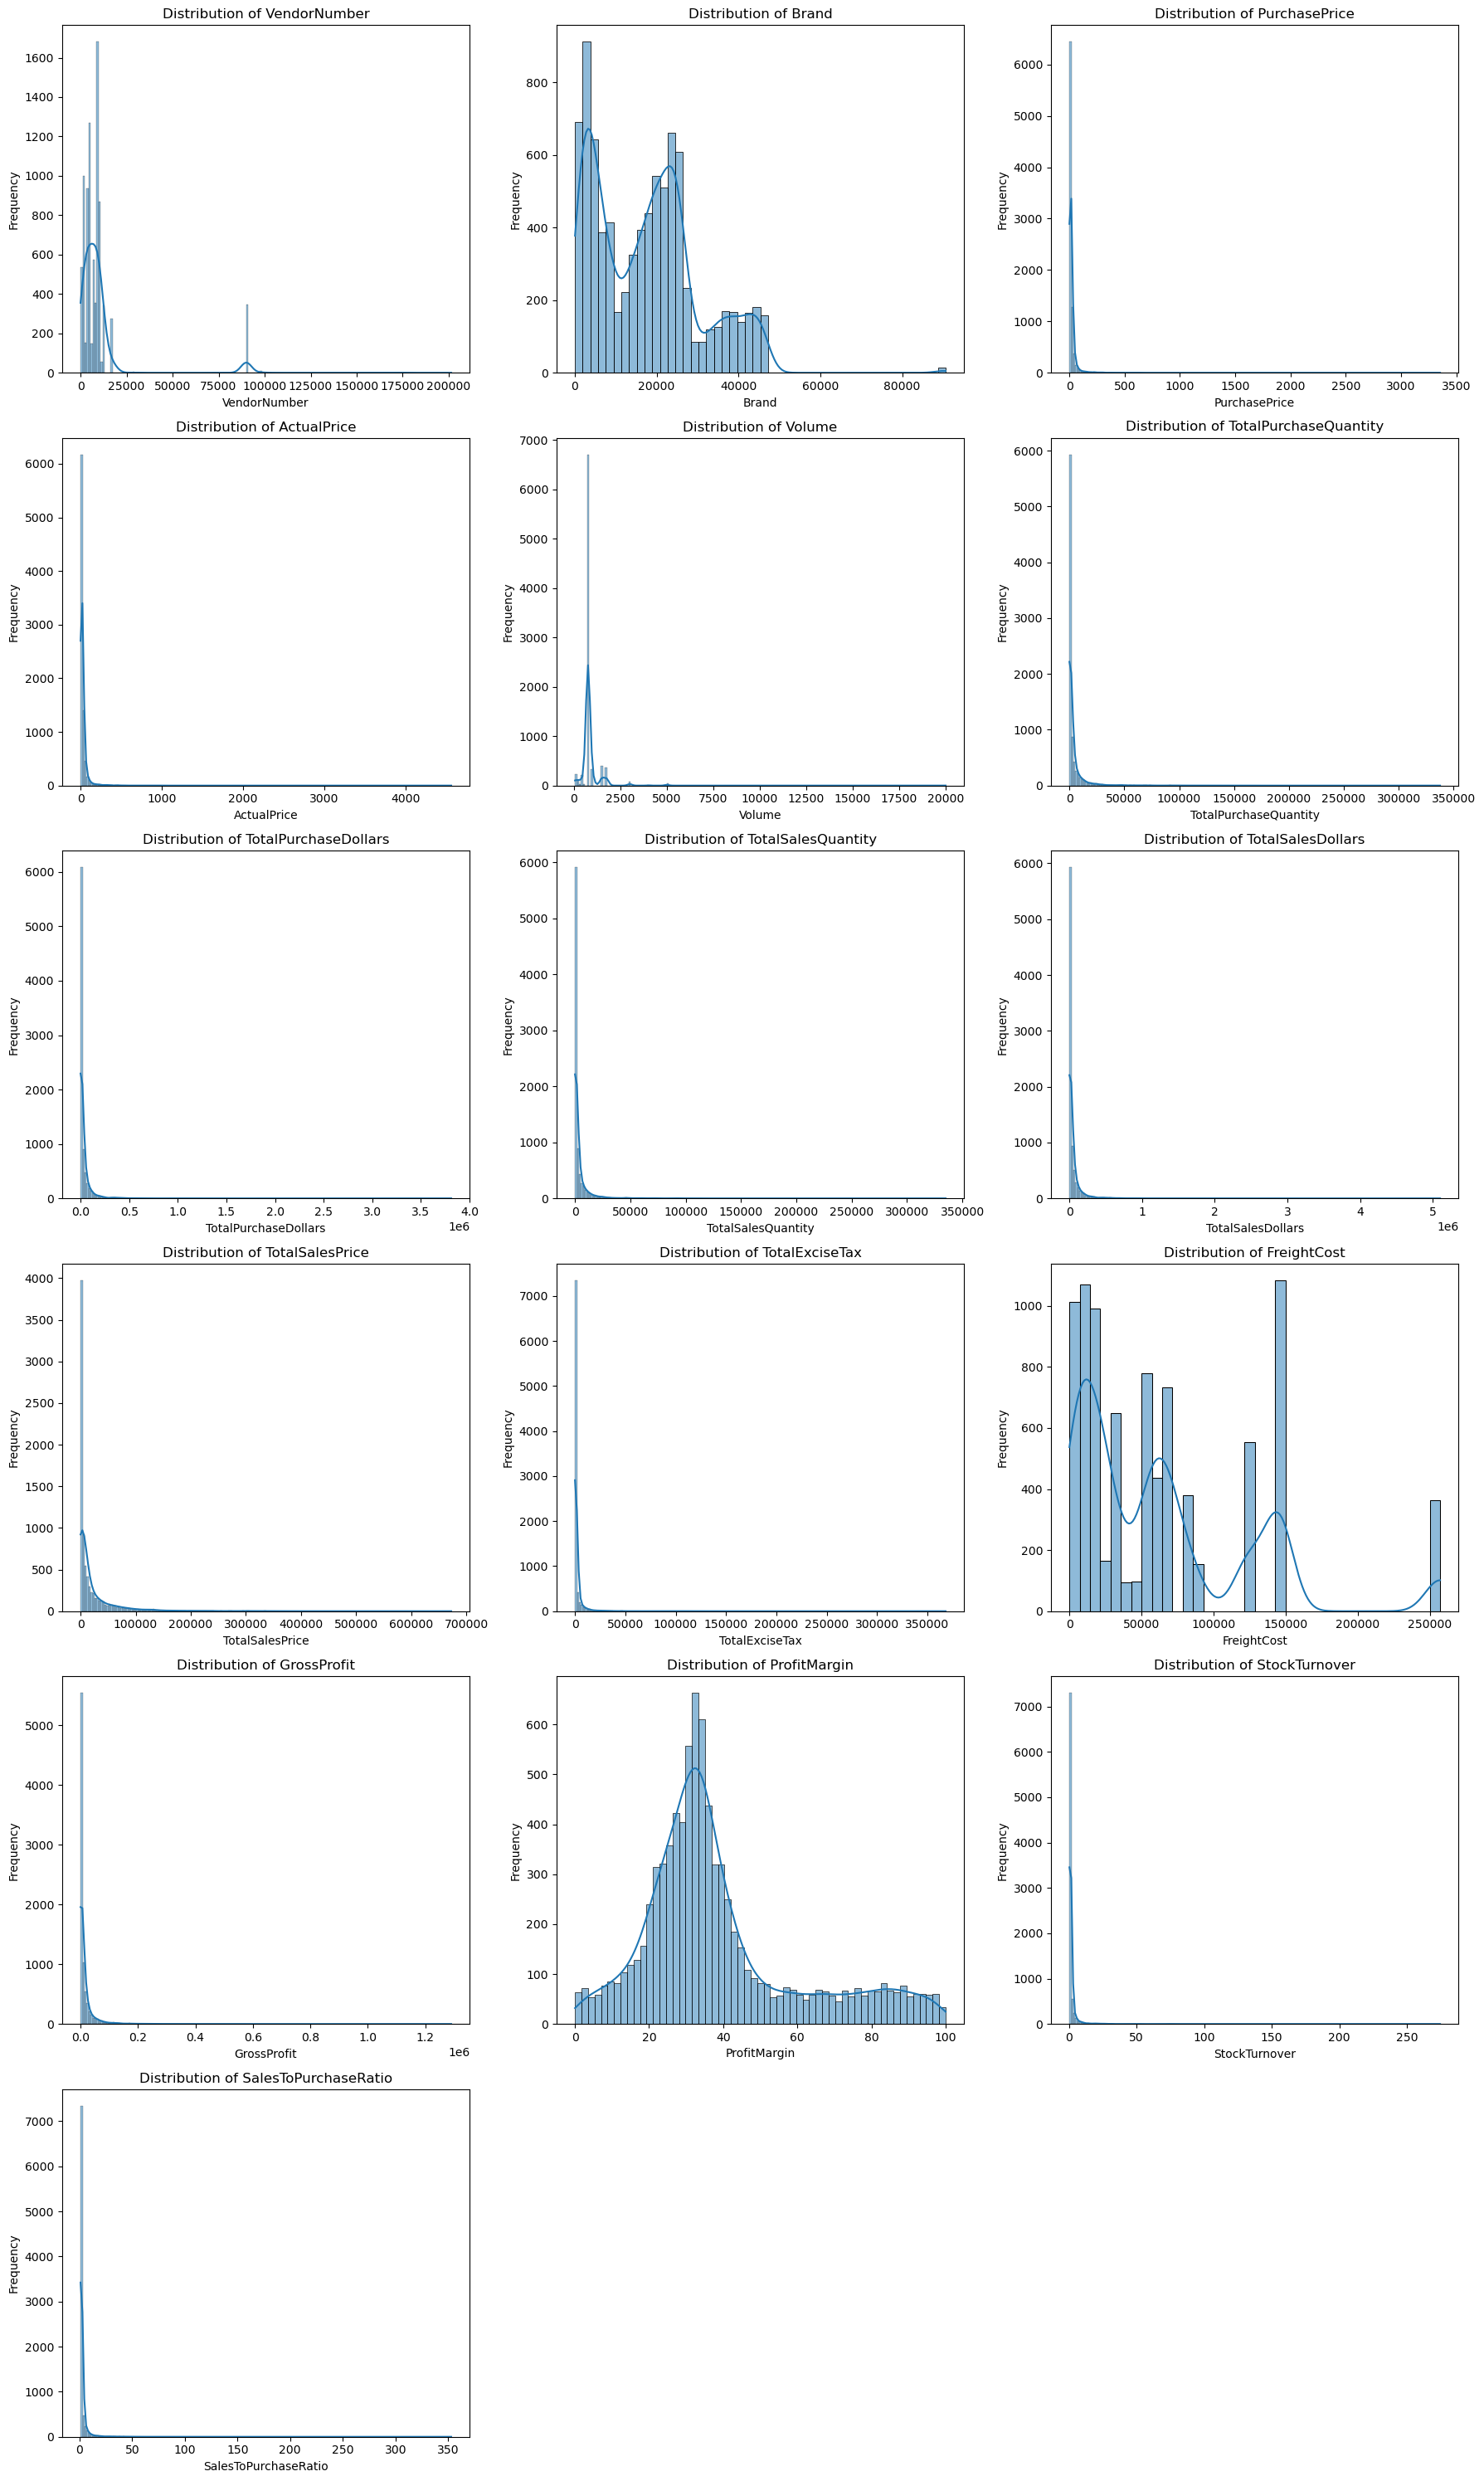

In [19]:
#distribution plot
# Select all numerical columns automatically
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Define subplot grid
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot distributions
for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

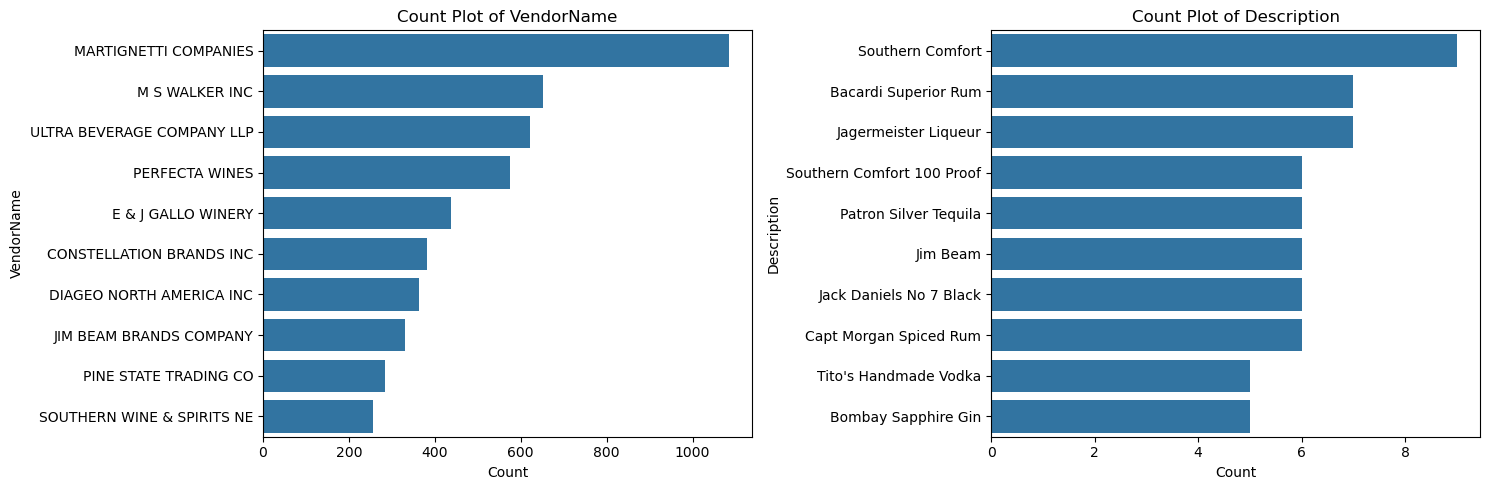

In [20]:
# count plot of catagorical olums
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Create subplots
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().head(10).index,  # Top 10 categories
        ax=axes[i]
    )
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

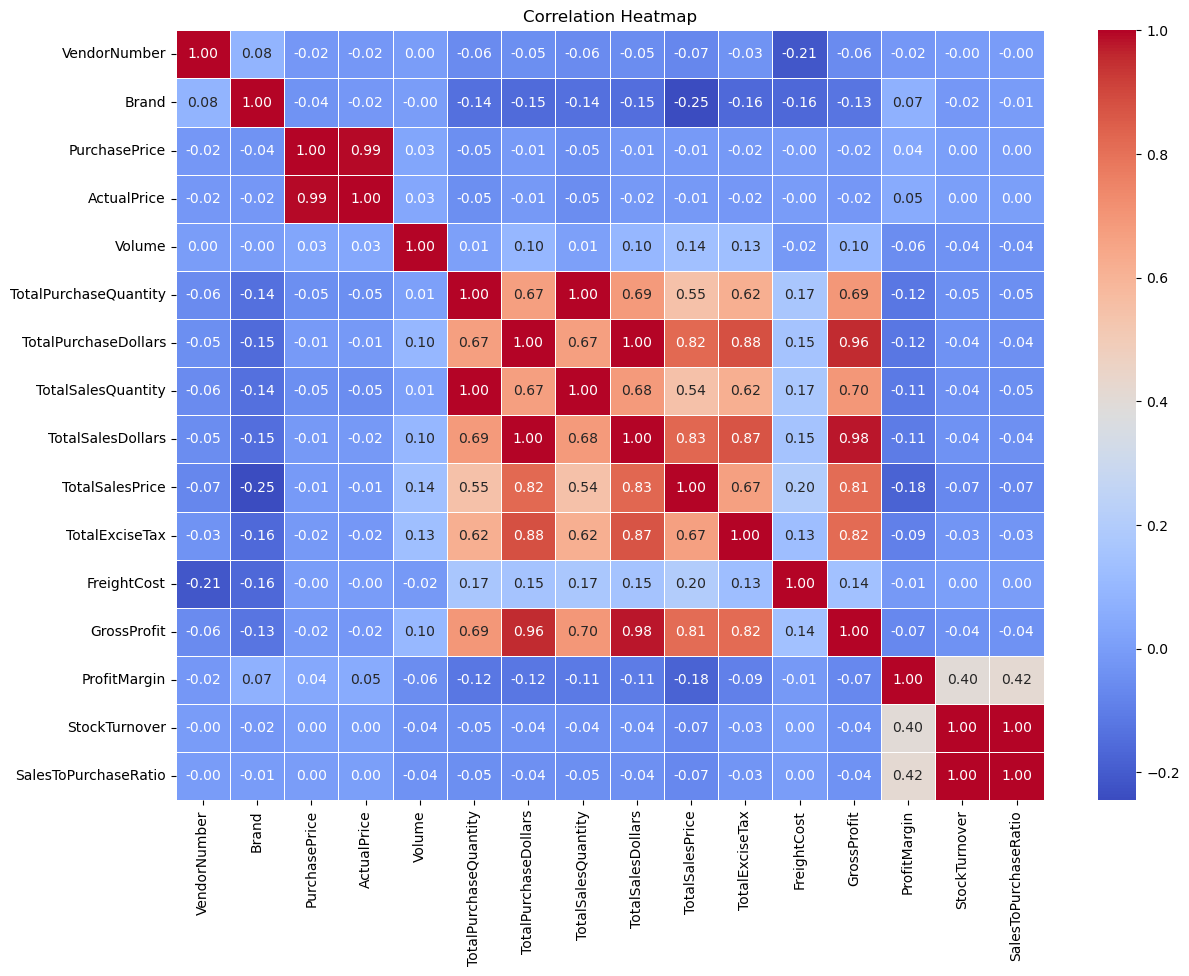

In [21]:
#correlation heatmapp
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_cols.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

### Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.


### Data Analysis
* identify brands which needs Promotional and Pricing Adjustment
* High Profit Margin (good profitability)
* Low Sales Performance (low sales quantity or sales dollars)

In [5]:
brand_analysis = (
    df
    .groupby('Brand')
    .agg({
        'TotalSalesQuantity': 'sum',
        'TotalSalesDollars': 'sum',
        'ProfitMargin': 'mean'
    })
    .reset_index()
)


In [6]:
brand_analysis

,Brand,TotalSalesQuantity,TotalSalesDollars,ProfitMargin
0,58,3446,43341.54,23.99
1,60,1775,18716.25,35.43
2,61,312,4364.88,24.23
3,62,3125,119863.75,23.46
4,63,2778,112249.22,22.53
...,...,...,...,...
8540,90088,26,3509.74,84.19
8541,90089,159,19078.41,86.93
8542,90090,15,9749.85,72.41
8543,90609,59,1474.41,98.85


In [7]:
# Calculate thresholds
low_sales = brand_analysis['TotalSalesDollars'].quantile(0.25)
high_margin = brand_analysis['ProfitMargin'].quantile(0.75)

In [8]:
# Brands with low sales but high margins
promotion_candidates = brand_analysis[
    (brand_analysis['TotalSalesDollars'] <= low_sales) &
    (brand_analysis['ProfitMargin'] >= high_margin)
].sort_values('ProfitMargin', ascending=False)

promotion_candidates.head(20)

,Brand,TotalSalesQuantity,TotalSalesDollars,ProfitMargin
7957,40583,110,1208.90,99.39
1209,3065,86,85.14,99.17
2313,6127,72,143.28,98.97
6277,24559,51,1019.49,98.68
2725,8151,415,410.85,98.62
3301,12253,92,735.08,98.58
270,788,52,779.48,98.56
1866,4424,86,945.14,98.22
1835,4357,40,399.60,98.13
2878,8563,42,461.58,98.11


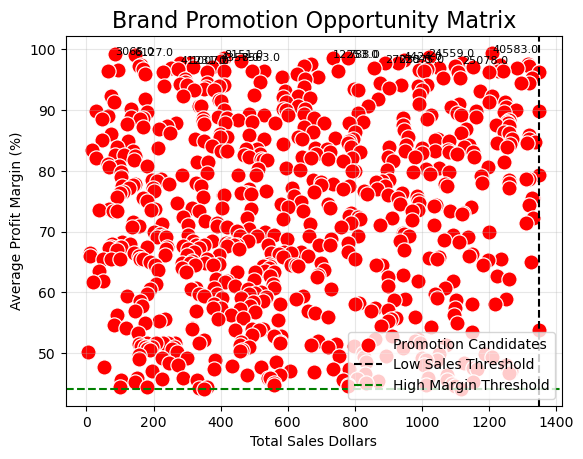

In [31]:
# Promotion candidates
sns.scatterplot(
    data=promotion_candidates,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    s=120,
    label='Promotion Candidates'
)

# Annotate top candidates
for _, row in promotion_candidates.head(15).iterrows():
    plt.annotate(
        row['Brand'],
        (row['TotalSalesDollars'], row['ProfitMargin']),
        fontsize=8
    )

# Quadrant lines
plt.axvline(
    low_sales,
    color='black',
    linestyle='--',
    label='Low Sales Threshold'
)

plt.axhline(
    high_margin,
    color='green',
    linestyle='--',
    label='High Margin Threshold'
)

plt.title('Brand Promotion Opportunity Matrix', fontsize=16)
plt.xlabel('Total Sales Dollars')
plt.ylabel('Average Profit Margin (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### which vendor and brands demonstratethe hghest sales performanes

In [21]:
top_vendors = (
    df
    .groupby('VendorName')
    .agg({
        'TotalSalesDollars': 'sum',
        'TotalSalesQuantity': 'sum'
    })
    .reset_index()
    .sort_values('TotalSalesDollars', ascending=False)
)

top_vendors['TotalSalesDollars(M)'] = (
    top_vendors['TotalSalesDollars'] / 1_000_000
).round(2)

top_vendors.head(10)

,VendorName,TotalSalesDollars,TotalSalesQuantity,TotalSalesDollars(M)
25,DIAGEO NORTH AMERICA INC,67990099.42,5383490,67.99
57,MARTIGNETTI COMPANIES,39330359.36,2488162,39.33
68,PERNOD RICARD USA,32063196.19,1605783,32.06
46,JIM BEAM BRANDS COMPANY,31423020.46,2527234,31.42
6,BACARDI USA INC,24854817.14,1429076,24.85
20,CONSTELLATION BRANDS INC,24218745.65,2283566,24.22
30,E & J GALLO WINERY,18399899.46,1781398,18.40
11,BROWN-FORMAN CORP,18247230.65,977635,18.25
106,ULTRA BEVERAGE COMPANY LLP,16502544.31,977939,16.50
53,M S WALKER INC,14706458.51,1294175,14.71


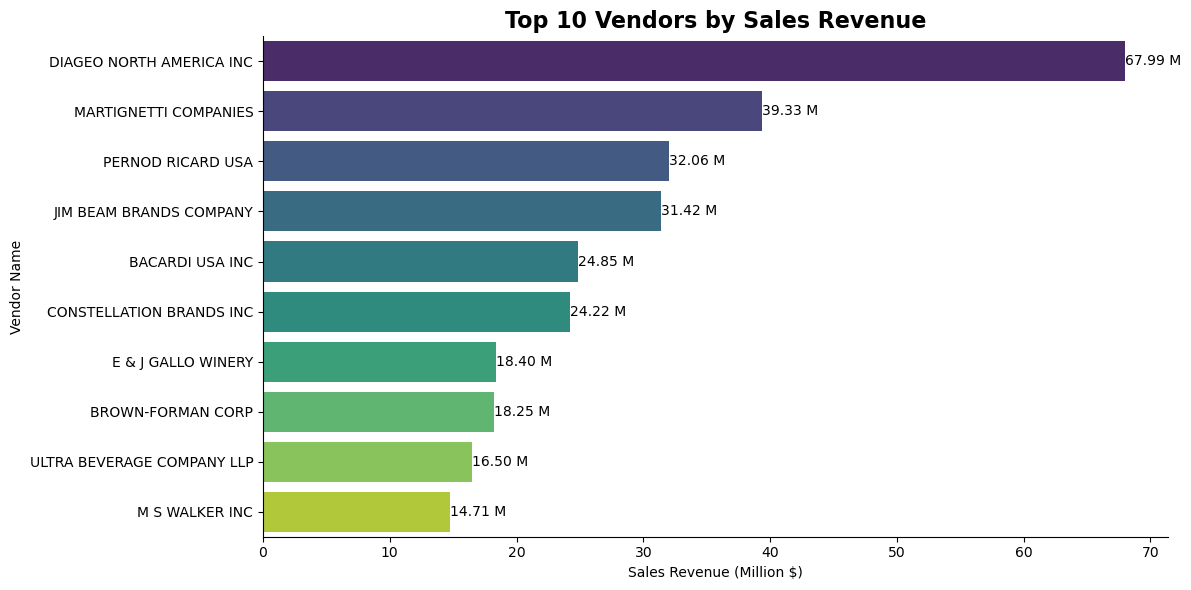

In [22]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_vendors.head(10),
    x='TotalSalesDollars(M)',
    y='VendorName',
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f M')

plt.title(
    'Top 10 Vendors by Sales Revenue',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sales Revenue (Million $)')
plt.ylabel('Vendor Name')

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
top_brands = (
    df
    .groupby(['Brand', 'Description'])
    .agg({
        'TotalSalesDollars': 'sum',
        'TotalSalesQuantity': 'sum'
    })
    .reset_index()
    .sort_values('TotalSalesDollars', ascending=False)
)

top_brands['TotalSalesDollars(M)'] = (
    top_brands['TotalSalesDollars'] / 1_000_000
).round(2)

top_brands.head(10)

,Brand,Description,TotalSalesDollars,TotalSalesQuantity,TotalSalesDollars(M)
498,1233,Jack Daniels No 7 Black,5101919.51,142049,5.10
1361,3405,Tito's Handmade Vodka,4819073.49,160247,4.82
2689,8068,Absolut 80 Proof,4538120.60,187140,4.54
1784,4261,Capt Morgan Spiced Rum,4475972.88,200412,4.48
1427,3545,Ketel One Vodka,4223107.62,135838,4.22
1608,3858,Grey Goose Vodka,3383912.40,141860,3.38
942,2589,Jameson Irish Whiskey,2773367.73,69627,2.77
1399,3489,Tanqueray,2640491.19,90481,2.64
1222,3102,Smirnoff Traveler,2592041.35,148265,2.59
551,1376,Jim Beam,2435393.39,107061,2.44


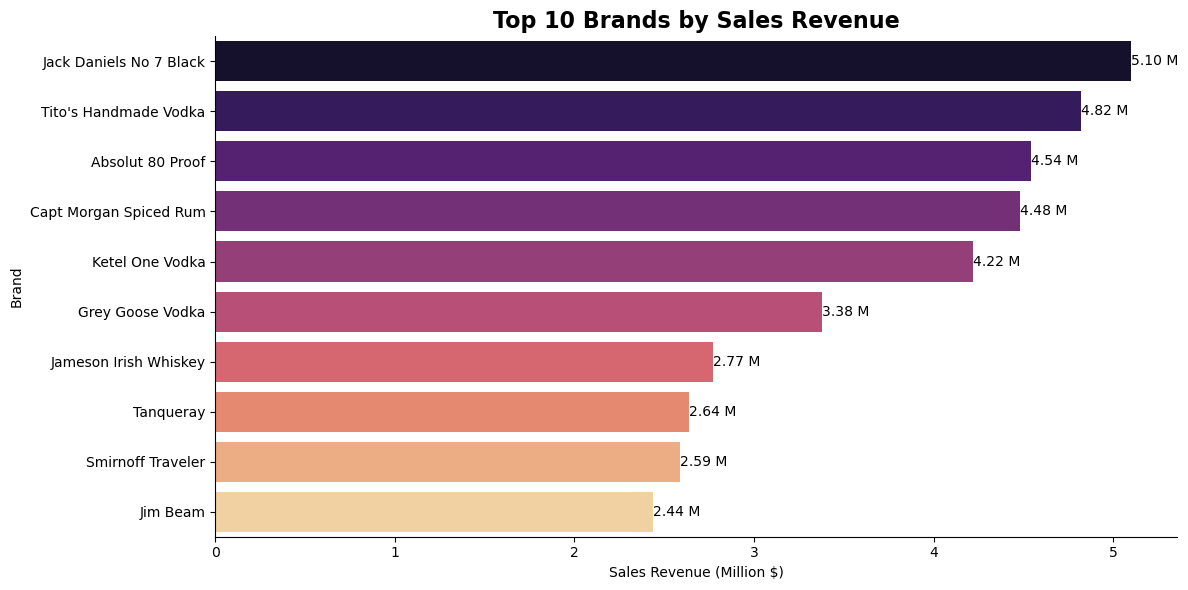

In [25]:
top_brands['TotalSalesDollars(M)'] = (
    top_brands['TotalSalesDollars'] / 1_000_000
).round(2)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_brands.head(10),
    x='TotalSalesDollars(M)',
    y='Description',
    palette='magma'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f M')

plt.title(
    'Top 10 Brands by Sales Revenue',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sales Revenue (Million $)')
plt.ylabel('Brand')

sns.despine()
plt.tight_layout()
plt.show()

### Which vendor contributes the most to Total Purchase Dollars

In [15]:
vendor_performance = (
    df
    .groupby('VendorName')
    .agg({
        'TotalPurchaseDollars': 'sum',
        'GrossProfit': 'sum',
        'TotalSalesDollars': 'sum'
    })
    .reset_index()
    .sort_values('TotalPurchaseDollars', ascending=False)
)

vendor_performance.head(10)
vendor_performance.shape

(119, 4)

In [5]:
vendor_performance['PurchaseContribution%'] = (vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum())*100

In [8]:
round(vendor_performance.sort_values('PurchaseContribution%', ascending = False), 2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [12]:
# Format monetary columns to Millions (M)
vendor_performance['TotalPurchaseDollars'] = (
    vendor_performance['TotalPurchaseDollars']
    .apply(lambda x: f'{x/1_000_000:.2f}M')
)

vendor_performance['GrossProfit'] = (
    vendor_performance['GrossProfit']
    .apply(lambda x: f'{x/1_000_000:.2f}M')
)

vendor_performance['TotalSalesDollars'] = (
    vendor_performance['TotalSalesDollars']
    .apply(lambda x: f'{x/1_000_000:.2f}M')
)

# Display the result
vendor_performance.head()

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [14]:
top_vendor =  vendor_performance.head(10)

In [17]:
top_vendor['PurchaseContribution%'].sum()

np.float64(65.68960039360739)

In [18]:
top_vendor

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [19]:
top_vendor['Cumulative_contribuion%'] = top_vendor['PurchaseContribution%'].cumsum()


In [20]:
top_vendor

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_contribuion%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


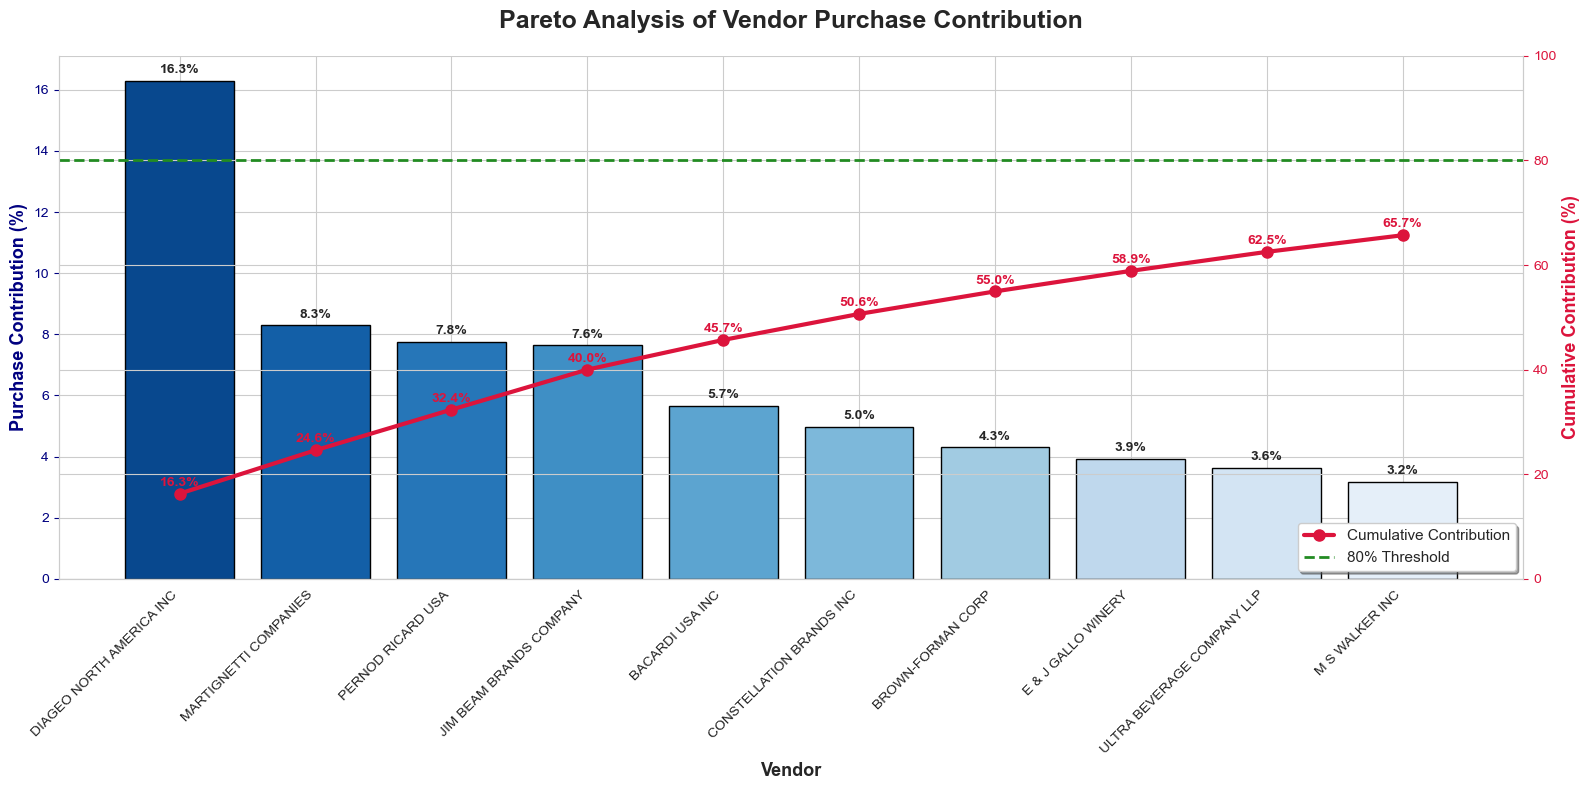

In [23]:
# Style
sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(16, 8))

# ------------------ Bar Plot ------------------
bars = ax1.bar(
    top_vendor['VendorName'],
    top_vendor['PurchaseContribution%'],
    color=sns.color_palette("Blues_r", len(top_vendor)),
    edgecolor='black',
    linewidth=1
)

# Bar labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.25,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_xlabel('Vendor', fontsize=13, fontweight='bold')
ax1.set_ylabel('Purchase Contribution (%)',
               fontsize=13,
               fontweight='bold',
               color='navy')

ax1.tick_params(axis='y', colors='navy')
ax1.set_xticklabels(
    top_vendor['VendorName'],
    rotation=45,
    ha='right',
    fontsize=10
)

# ------------------ Pareto Line ------------------
ax2 = ax1.twinx()

ax2.plot(
    top_vendor['VendorName'],
    top_vendor['Cumulative_contribuion%'],
    color='crimson',
    marker='o',
    markersize=8,
    linewidth=3,
    label='Cumulative Contribution'
)

# Point labels
for x, y in zip(
    top_vendor['VendorName'],
    top_vendor['Cumulative_contribuion%']
):
    ax2.text(
        x,
        y + 1.5,
        f'{y:.1f}%',
        color='crimson',
        fontsize=10,
        ha='center',
        fontweight='bold'
    )

# 80% Reference Line
ax2.axhline(
    80,
    color='forestgreen',
    linestyle='--',
    linewidth=2,
    label='80% Threshold'
)

ax2.set_ylabel(
    'Cumulative Contribution (%)',
    fontsize=13,
    fontweight='bold',
    color='crimson'
)

ax2.tick_params(axis='y', colors='crimson')
ax2.set_ylim(0, 100)

# ------------------ Title ------------------
plt.title(
    'Pareto Analysis of Vendor Purchase Contribution',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Legend
ax2.legend(
    loc='lower right',
    fontsize=11,
    frameon=True,
    shadow=True
)

# Remove top spines
sns.despine(left=False, right=False)

plt.tight_layout()
plt.show()

### How much total procurement is dependent on the top vendor

In [24]:
# Total procurement contribution of the Top 10 vendors
top_10_dependency = top_vendor.head(10)['PurchaseContribution%'].sum()

print(f"Top 10 Vendors contribute {top_10_dependency:.2f}% of the total procurement.")

Top 10 Vendors contribute 65.69% of the total procurement.


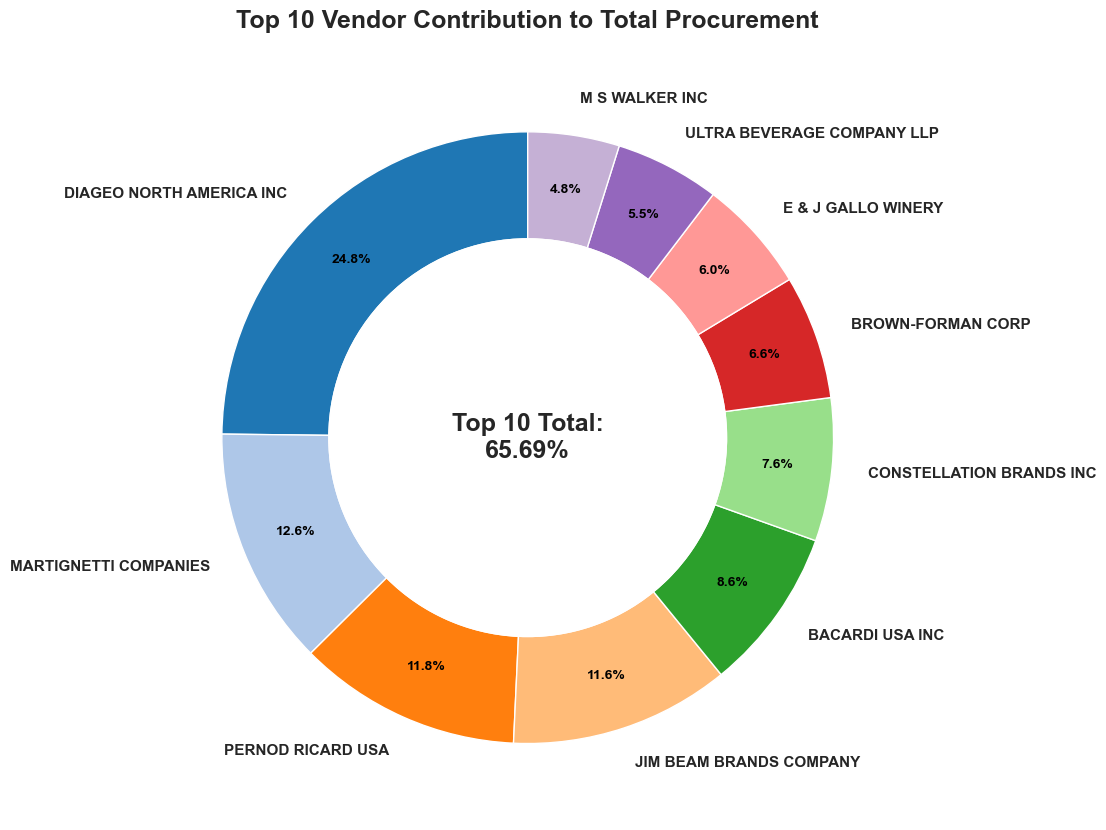

In [27]:
# Data
labels = top_vendor['VendorName']
sizes = top_vendor['PurchaseContribution%']

# Color palette
colors = plt.cm.tab20.colors[:len(top_vendor)]

plt.figure(figsize=(11, 11))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.82,
    labeldistance=1.12,
    wedgeprops=dict(width=0.35, edgecolor='white')
)

# Center circle
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

# Center text
plt.text(
    0,
    0,
    f"Top 10 Total:\n{sizes.sum():.2f}%",
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

# Improve text appearance
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title(
    "Top 10 Vendor Contribution to Total Procurement",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [30]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [32]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels = ["Small", "Medium", "Large"])

In [34]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.00,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.00,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.00,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.00,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.00,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.00,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,22.33,28.06,0.39,Small
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.00,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,1.00,1.34,0.74,Small
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.00,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.97,72.00,97.47,1.47,Small
8563,7245,PROXIMO SPIRITS INC.,3065,Three Olives Grape Vodka,0.71,0.99,50.00,1,0.71,86,85.14,33.66,4.46,38994.78,84.43,99.17,86.00,119.92,0.71,Small


In [35]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.07
Medium,15.48
Large,10.77


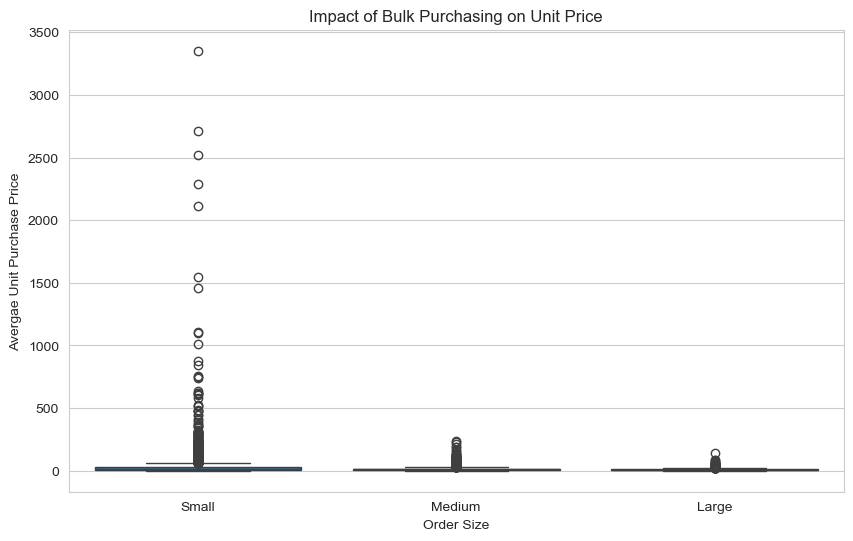

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Avergae Unit Purchase Price")
plt.show()

### Key Insights

- **Vendors purchasing in bulk (large order sizes)** receive the **lowest average unit purchase price** (approximately **$10.78 per unit**), indicating greater opportunities for cost savings and improved profit margins when inventory is managed efficiently.

- The **difference in unit price between small and large orders is substantial** (approximately **72% lower** for large orders), demonstrating a significant volume-based pricing advantage.

- These findings suggest that the organization's **bulk purchasing strategy effectively incentivizes larger order quantities**, enabling vendors to reduce procurement costs while potentially increasing overall profitability, despite lower revenue on a per-unit basis.

### Which vendors have low inventory turnover, indicating excess stock and slow moving_product 

In [11]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.62
HIGHLAND WINE MERCHANTS LLC,0.71
PARK STREET IMPORTS LLC,0.75
Circa Wines,0.76
Dunn Wine Brokers,0.77
CENTEUR IMPORTS LLC,0.77
SMOKY QUARTZ DISTILLERY LLC,0.78
TAMWORTH DISTILLING,0.80
THE IMPORTED GRAPE LLC,0.81


### how much capital is locked in unsold invenotry per vendor and whch vendor contributes most to it

In [17]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]

In [16]:
df.drop(columns=['UnsoldInventoryValue'], inplace=True)

In [19]:
print("Total Unsold Capital:", f"{df['UnsoldInventoryValue'].sum()/1_000_000:.2f}M")

Total Unsold Capital: 2.71M


In [20]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = (df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index())

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)

# Format values in Millions
inventory_value_per_vendor["UnsoldInventoryValue"] = (inventory_value_per_vendor["UnsoldInventoryValue"].apply(lambda x: f"${x/1_000_000:.2f}M"))

# Display Top 10 Vendors
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,$0.72M
46,JIM BEAM BRANDS COMPANY,$0.55M
68,PERNOD RICARD USA,$0.47M
116,WILLIAM GRANT & SONS INC,$0.40M
30,E & J GALLO WINERY,$0.23M
79,SAZERAC CO INC,$0.20M
11,BROWN-FORMAN CORP,$0.18M
20,CONSTELLATION BRANDS INC,$0.13M
61,MOET HENNESSY USA INC,$0.13M
77,REMY COINTREAU USA INC,$0.12M


### what is th 95% confidence interval for profit margin of top-performing and low performing vendor

In [21]:
# Define thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Split vendors based on sales performance
top_vendor = df[df["TotalSalesDollars"] >= top_threshold]
low_vendor = df[df["TotalSalesDollars"] <= low_threshold]

In [24]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):

    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)

    margin_error = t.ppf((1 + confidence) / 2, n - 1) * (std / np.sqrt(n))

    lower = mean - margin_error
    upper = mean + margin_error

    return mean, lower, upper

In [25]:
top_mean, top_lower, top_upper = confidence_interval(top_vendor["ProfitMargin"])

low_mean, low_lower, low_upper = confidence_interval(low_vendor["ProfitMargin"])

In [26]:
print("Top Performing Vendors")
print(f"Mean Profit Margin : {top_mean:.2f}%")
print(f"95% Confidence Interval : ({top_lower:.2f}%, {top_upper:.2f}%)")

print()

print("Low Performing Vendors")
print(f"Mean Profit Margin : {low_mean:.2f}%")
print(f"95% Confidence Interval : ({low_lower:.2f}%, {low_upper:.2f}%)")

Top Performing Vendors
Mean Profit Margin : 31.21%
95% Confidence Interval : (30.77%, 31.65%)

Low Performing Vendors
Mean Profit Margin : 41.56%
95% Confidence Interval : (40.49%, 42.63%)


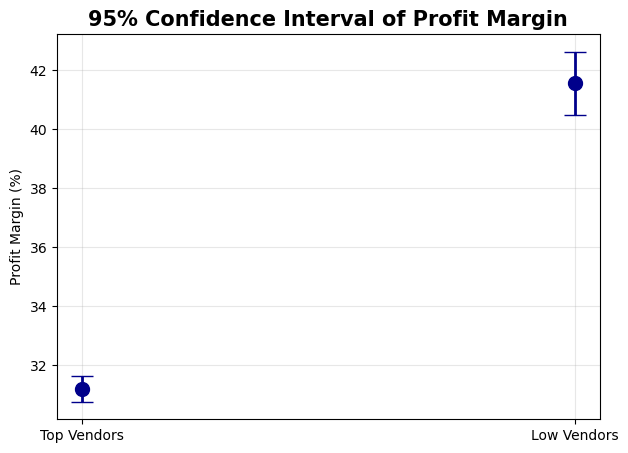

In [27]:
means = [top_mean, low_mean]

lower_error = [top_mean - top_lower,
               low_mean - low_lower]

upper_error = [top_upper - top_mean,
               low_upper - low_mean]

plt.figure(figsize=(7,5))

plt.errorbar(
    ["Top Vendors", "Low Vendors"],
    means,
    yerr=[lower_error, upper_error],
    fmt='o',
    color='darkblue',
    capsize=8,
    linewidth=2,
    markersize=10
)

plt.title(
    "95% Confidence Interval of Profit Margin",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Profit Margin (%)")
plt.grid(alpha=0.3)

plt.show()

### 95% Confidence Interval Analysis of Profit Margin

A 95% confidence interval was estimated for the average profit margin of top-performing and low-performing vendors based on their sales performance.

#### Key Insights

- The **low-performing vendors** exhibit a **higher average profit margin (~41.5%)** compared to the **top-performing vendors (~31.2%)**.

- The **95% confidence intervals do not overlap**, indicating that the difference in average profit margins between the two groups is statistically significant.

- Although top-performing vendors generate substantially higher sales volumes, they operate with relatively **lower profit margins**, suggesting a high-volume, lower-margin business strategy.

- In contrast, low-performing vendors generate fewer sales but maintain **higher profit margins**, indicating they may be selling premium or niche products with greater per-unit profitability.

- This analysis demonstrates that **higher sales do not necessarily translate into higher profit margins**. Revenue and profitability should therefore be evaluated together when assessing vendor performance.

#### Business Recommendation

- Continue leveraging top-performing vendors to drive revenue while exploring opportunities to improve their margins through pricing optimization, procurement cost reductions, or operational efficiencies.

- For low-performing vendors, investigate whether their higher-margin products can be promoted more effectively to increase sales volume without significantly eroding profitability.

- Vendor performance evaluations should incorporate both **sales performance** and **profitability metrics** to support more balanced procurement and inventory decisions.

## Is there a significant difference in profit margins between top-performing and low-performing vendors? 📊

### Hypothesis:

**H₀ (Null Hypothesis):** There is **no significant difference** in the mean profit margins of top-performing and low-performing vendors.

**H₁ (Alternative Hypothesis):** The mean profit margins of top-performing and low-performing vendors are **significantly different**.


In [30]:
# Define thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Create groups
top_vendor = df[df["TotalSalesDollars"] >= top_threshold]
low_vendor = df[df["TotalSalesDollars"] <= low_threshold]

# Perform Welch's Independent t-test
t_stat, p_value = ttest_ind(
    top_vendor["ProfitMargin"],
    low_vendor["ProfitMargin"],
    equal_var=False
)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

# Conclusion
alpha = 0.05

if p_value < alpha:
    print("\nReject the Null Hypothesis (H₀)")
    print("There is a statistically significant difference in the mean profit margins between top-performing and low-performing vendors.")
else:
    print("\nFail to Reject the Null Hypothesis (H₀)")
    print("There is no statistically significant difference in the mean profit margins between top-performing and low-performing vendors.")

T-statistic : -17.5815
P-value     : 0.0000

Reject the Null Hypothesis (H₀)
There is a statistically significant difference in the mean profit margins between top-performing and low-performing vendors.
